In [ ]:
from openai import OpenAI
import os
os.environ["OPENAI_API_KEY"] = ""
import json
import tiktoken
from bs4 import BeautifulSoup
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [8]:
def strip_code_fences(text: str) -> str:
    """
    Remove Markdown code fences like ```latex ... ``` from model output.
    """
    # Remove starting and ending triple backticks with optional language tag
    if text.startswith("```"):
        # split into lines, drop first and last if they're code fences
        lines = text.splitlines()
        if lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines)
    return text

In [9]:
intention_list = [
    "Idea Generation",
    "Idea Organization",
    "Section Planning",
    "Text Production",
    "Object Insertion",
    "Citation Integration",
    "Cross-reference",
    "Macro Insertion",
    "Fluency",
    "Coherence",
    "Clarity",
    "Structural",
    "Linguistic Style",
    "Scientific Accuracy",
    "Visual Formatting",
]

category_map = {
    "Planning": intention_list[:3],   # 3 labels
    "Implementation": intention_list[3:8],  # 5 labels
    "Revision": intention_list[8:],   # 7 labels
}
model = "gpt-5"

In [ ]:
model = "gpt-5"
for i in range(1, 6):
    folder = f"intent_session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"intent_session/project_{i}_intent_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    store = []
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output = strip_code_fences(raw_output)
            
            # human output
            human_output_folder = f"intent_session_experiment/human_output/{i}/{rec['index']}.txt"
            os.makedirs(os.path.dirname(human_output_folder), exist_ok=True)
            
            with open(human_output_folder, "w") as f:
                f.write(rec['after_text'])
            

### Span-level


In [10]:
import difflib

def extract_spans(before, after):
    before_tokens = before.split()
    after_tokens = after.split()
    matcher = difflib.SequenceMatcher(None, before_tokens, after_tokens)
    spans = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag != 'equal':  # any change = span
            spans.append((i1, i2))  # indices in BEFORE text
    
    return spans

def overlap(a, b):
    return max(0, min(a[1], b[1]) - max(a[0], b[0]))

def span_f1(pred_spans, gold_spans):
    tp = 0
    used = set()

    for p in pred_spans:
        matched = False
        for i, g in enumerate(gold_spans):
            if overlap(p, g) > 0 and i not in used:
                tp += 1
                used.add(i)
                matched = True
                break
        if not matched:
            pass  # FP counted later

    fp = len(pred_spans) - tp
    fn = len(gold_spans) - len(used)

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    return precision, recall, f1


In [11]:
for i in range(1, 6):
    folder = f"intent_session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"intent_session/project_{i}_intent_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    store = []
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output = strip_code_fences(raw_output)

            gold_spans = extract_spans(rec["before_text"], rec["after_text"])
            pred_spans = extract_spans(rec["before_text"], model_output)

            precision, recall, f1_span = span_f1(pred_spans, gold_spans)
            
            record = {
                "index": rec["index"],
                "duration": rec['duration'],
                "span_precision": precision,
                "span_recall": recall,
                "span_f1": f1_span,
                "label": rec['label']
            }
            store.append(record)
    
    output_file = f"intent_session_experiment/span_level/{model}/project_{i}.jsonl"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as f:
        for record in store:
            f.write(json.dumps(record) + "\n")
            

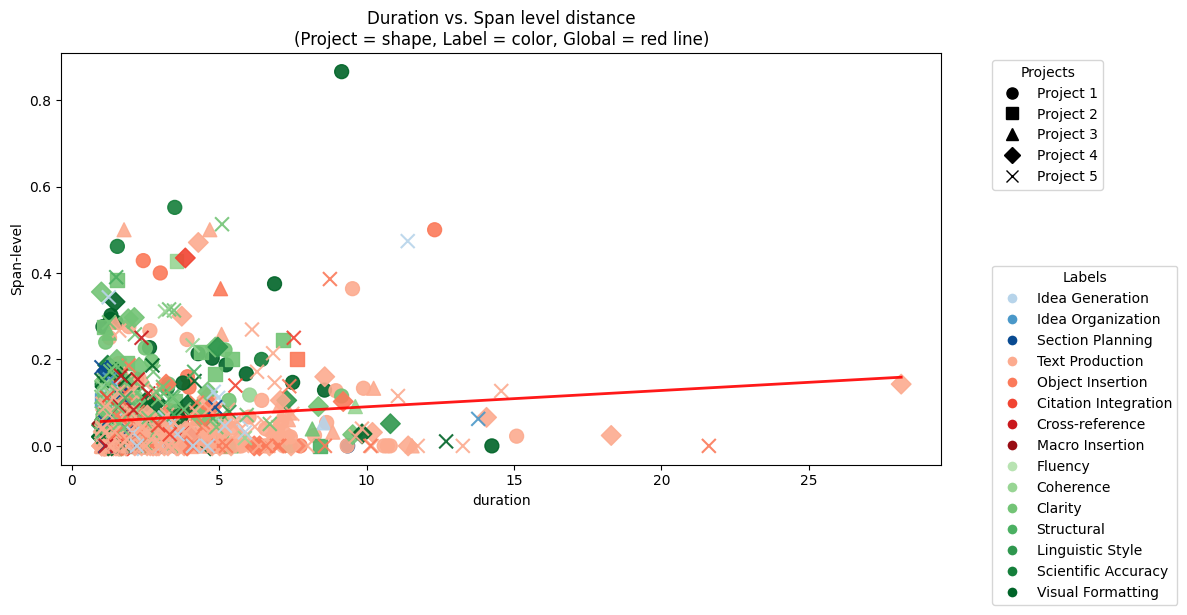

In [16]:
base_colors = {
    "Planning": "Blues",
    "Implementation": "Reds",
    "Revision": "Greens"
}

# Create a label → color mapping (same across all projects)
label_colors = {}
for cat, labs in category_map.items():
    cmap = cm.get_cmap(base_colors[cat])
    n = len(labs)
    shades = np.linspace(0.3, 0.9, n)
    for i, lab in enumerate(labs):
        label_colors[lab] = cmap(shades[i])

# Define markers for projects
project_markers = ["o", "s", "^", "D", "x"]  # 5 projects

plt.figure(figsize=(12, 6))

all_durations = []
all_levs = []

for proj_idx in range(1, 6):
    with open(f"intent_session_experiment/span_level/{model}/project_{proj_idx}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['span_f1'] for rec in data]
    label_list = [rec['label'] for rec in data]

    # collect for global regression
    all_durations.extend(duration_list)
    all_levs.extend(lev_list)

    point_colors = [label_colors[lab] for lab in label_list]

    plt.scatter(duration_list, lev_list,
                c=point_colors, marker=project_markers[proj_idx-1],
                s=100, alpha=0.9, label=f"Project {proj_idx}")

# --- Global regression line (all projects combined) ---
if len(all_durations) > 1:
    m, b = np.polyfit(all_durations, all_levs, 1)
    x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
    plt.plot(x_sorted, m * x_sorted + b,
             color="red", linewidth=2, alpha=0.9, label="Global trend")

# --- Legends ---
project_handles = [plt.Line2D([0], [0], marker=m, color='k', linestyle="",
                              markersize=8, label=f"Project {i+1}")
                   for i, m in enumerate(project_markers)]
proj_legend = plt.legend(handles=project_handles, title="Projects",
                         bbox_to_anchor=(1.05, 1), loc="upper left")

label_handles = [plt.Line2D([0], [0], marker='o', color='w',
                            label=lab, markerfacecolor=label_colors[lab],
                            markersize=8) for lab in label_colors]
plt.legend(handles=label_handles, title="Labels",
           bbox_to_anchor=(1.05, 0.5), loc="upper left")

plt.gca().add_artist(proj_legend)  # keep both legends

plt.xlabel("duration")
plt.ylabel("Span-level")
plt.title("Duration vs. Span level distance\n(Project = shape, Label = color, Global = red line)")
plt.tight_layout()
plt.savefig("figs/intention_session_duration_vs_span_level_aggregated_project.pdf")
plt.show()


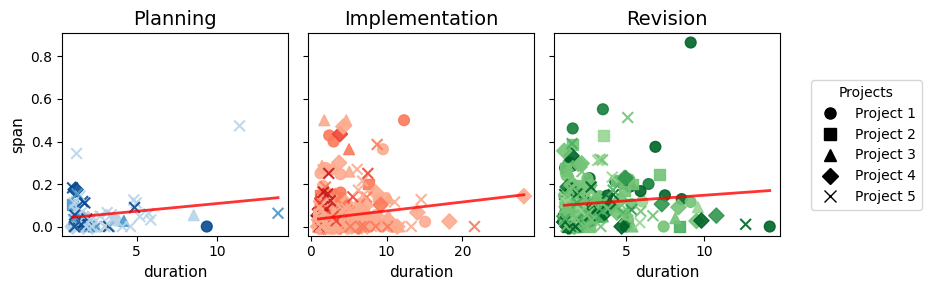

In [14]:
# Flatten all labels across categories
all_labels = []
for cat in base_colors:
    all_labels.extend(category_map[cat])

# 1 subplot per category
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

for ax, (cat, labs) in zip(axes, category_map.items()):
    all_durations = []
    all_levs = []

    for proj_idx in range(1, 6):
        with open(f"intent_session_experiment/span_level/{model}/project_{proj_idx}.jsonl", "r") as f:
            data = [json.loads(line) for line in f]

        # Collect all data for the labels in this category
        duration_list = [rec['duration'] for rec in data if rec['label'] in labs]
        lev_list      = [rec['span_f1'] for rec in data if rec['label'] in labs]
        label_list    = [rec['label'] for rec in data if rec['label'] in labs]

        # Add to global for regression
        all_durations.extend(duration_list)
        all_levs.extend(lev_list)

        # Scatter per project (color by label, marker by project)
        point_colors = [label_colors[lab] for lab in label_list]
        ax.scatter(duration_list, lev_list,
                   c=point_colors, marker=project_markers[proj_idx-1],
                   s=60, alpha=0.9, label=f"Project {proj_idx}")

    # --- Global regression line (per category, across all labels) ---
    if len(all_durations) > 1:
        m, b = np.polyfit(all_durations, all_levs, 1)
        x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
        ax.plot(x_sorted, m * x_sorted + b,
                color="red", linewidth=2, alpha=0.8, label="Global trend")

    ax.set_title(cat, fontsize=14)
    ax.set_xlabel("duration", fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel("span", fontsize=11)

# Shared legend (projects only, outside the plot)
project_handles = [
    plt.Line2D([0], [0], marker=m, color='k', linestyle="", markersize=8,
               label=f"Project {i+1}") 
    for i, m in enumerate(project_markers)
]
fig.legend(handles=project_handles, title="Projects",
           loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

plt.tight_layout()
# plt.savefig("figs/intention_session_by_category.pdf")
plt.show()


176
69
89
186
362


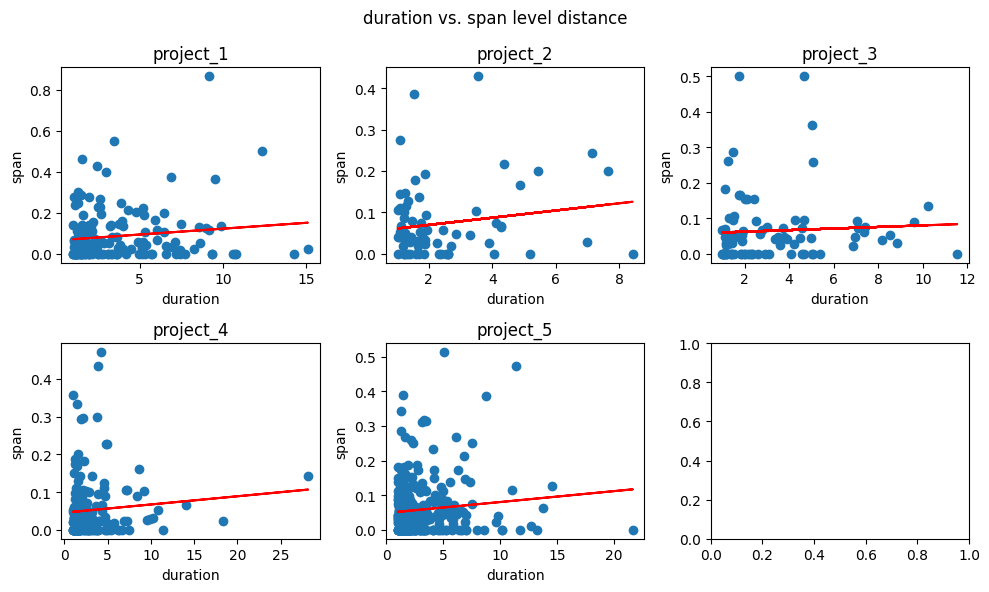

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))  # 2 rows, 3 columns
axes = axes.flatten()  # make it easier to index

for i in range(1, 6):  # 5 projects
    with open(f"intent_session_experiment/span_level/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    print(len(data)) 
    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['span_f1'] for rec in data]
    m, b = np.polyfit(duration_list, lev_list, 1)
    ax = axes[i-1]
    ax.plot(duration_list, np.array(duration_list)*m + b, color="red")
    ax.scatter(duration_list, lev_list)
    ax.set_xlabel("duration")
    ax.set_ylabel("span")
    ax.set_title(f"project_{i}")

fig.suptitle("duration vs. span level distance", fontsize=12)
plt.tight_layout()
plt.show()


### Edit distance

#### generate result

In [8]:
import Levenshtein

In [9]:
for i in range(1, 6):
    folder = f"intent_session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"intent_session/project_{i}_intent_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    store = []
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output = strip_code_fences(raw_output)

            lev = Levenshtein.ratio(rec['after_text'], model_output)
            
            record = {
                "index": rec["index"],
                "duration": rec['duration'],
                "levenshtein": lev,
                "label": rec['label']
            }
            store.append(record)
    
    output_file = f"intent_session_experiment/levenshtein/{model}/project_{i}.jsonl"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as f:
        for record in store:
            f.write(json.dumps(record) + "\n")
            

#### plot

176
69
89
186
362


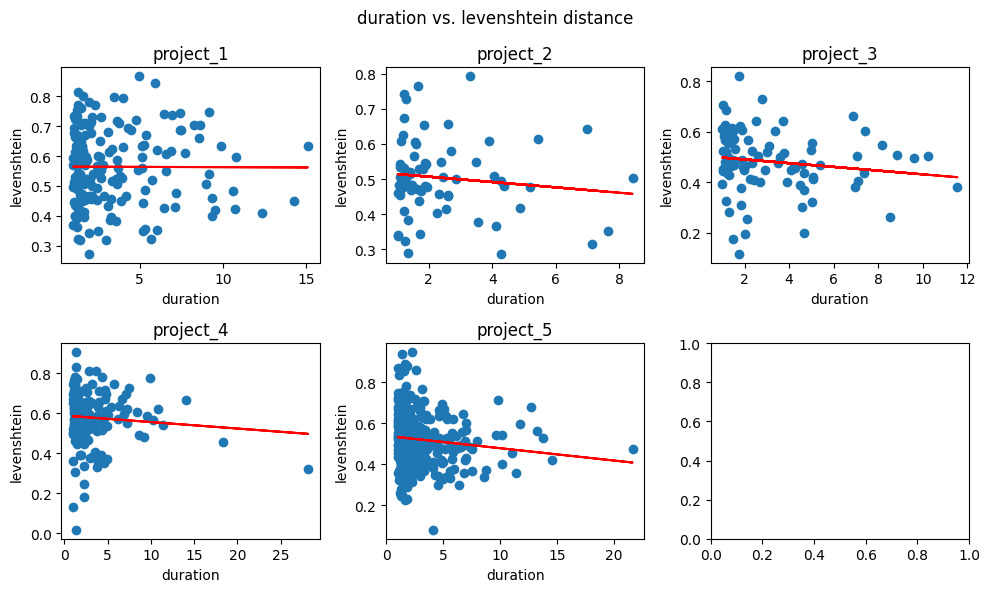

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))  # 2 rows, 3 columns
axes = axes.flatten()  # make it easier to index

for i in range(1, 6):  # 5 projects
    with open(f"intent_session_experiment/levenshtein/{model}/project_{i}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    print(len(data)) 
    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    m, b = np.polyfit(duration_list, lev_list, 1)
    ax = axes[i-1]
    ax.plot(duration_list, np.array(duration_list)*m + b, color="red")
    ax.scatter(duration_list, lev_list)
    ax.set_xlabel("duration")
    ax.set_ylabel("levenshtein")
    ax.set_title(f"project_{i}")

fig.suptitle("duration vs. levenshtein distance", fontsize=12)
plt.tight_layout()
plt.show()


15.09165
8.4190833333
11.54615
28.13845
21.61375


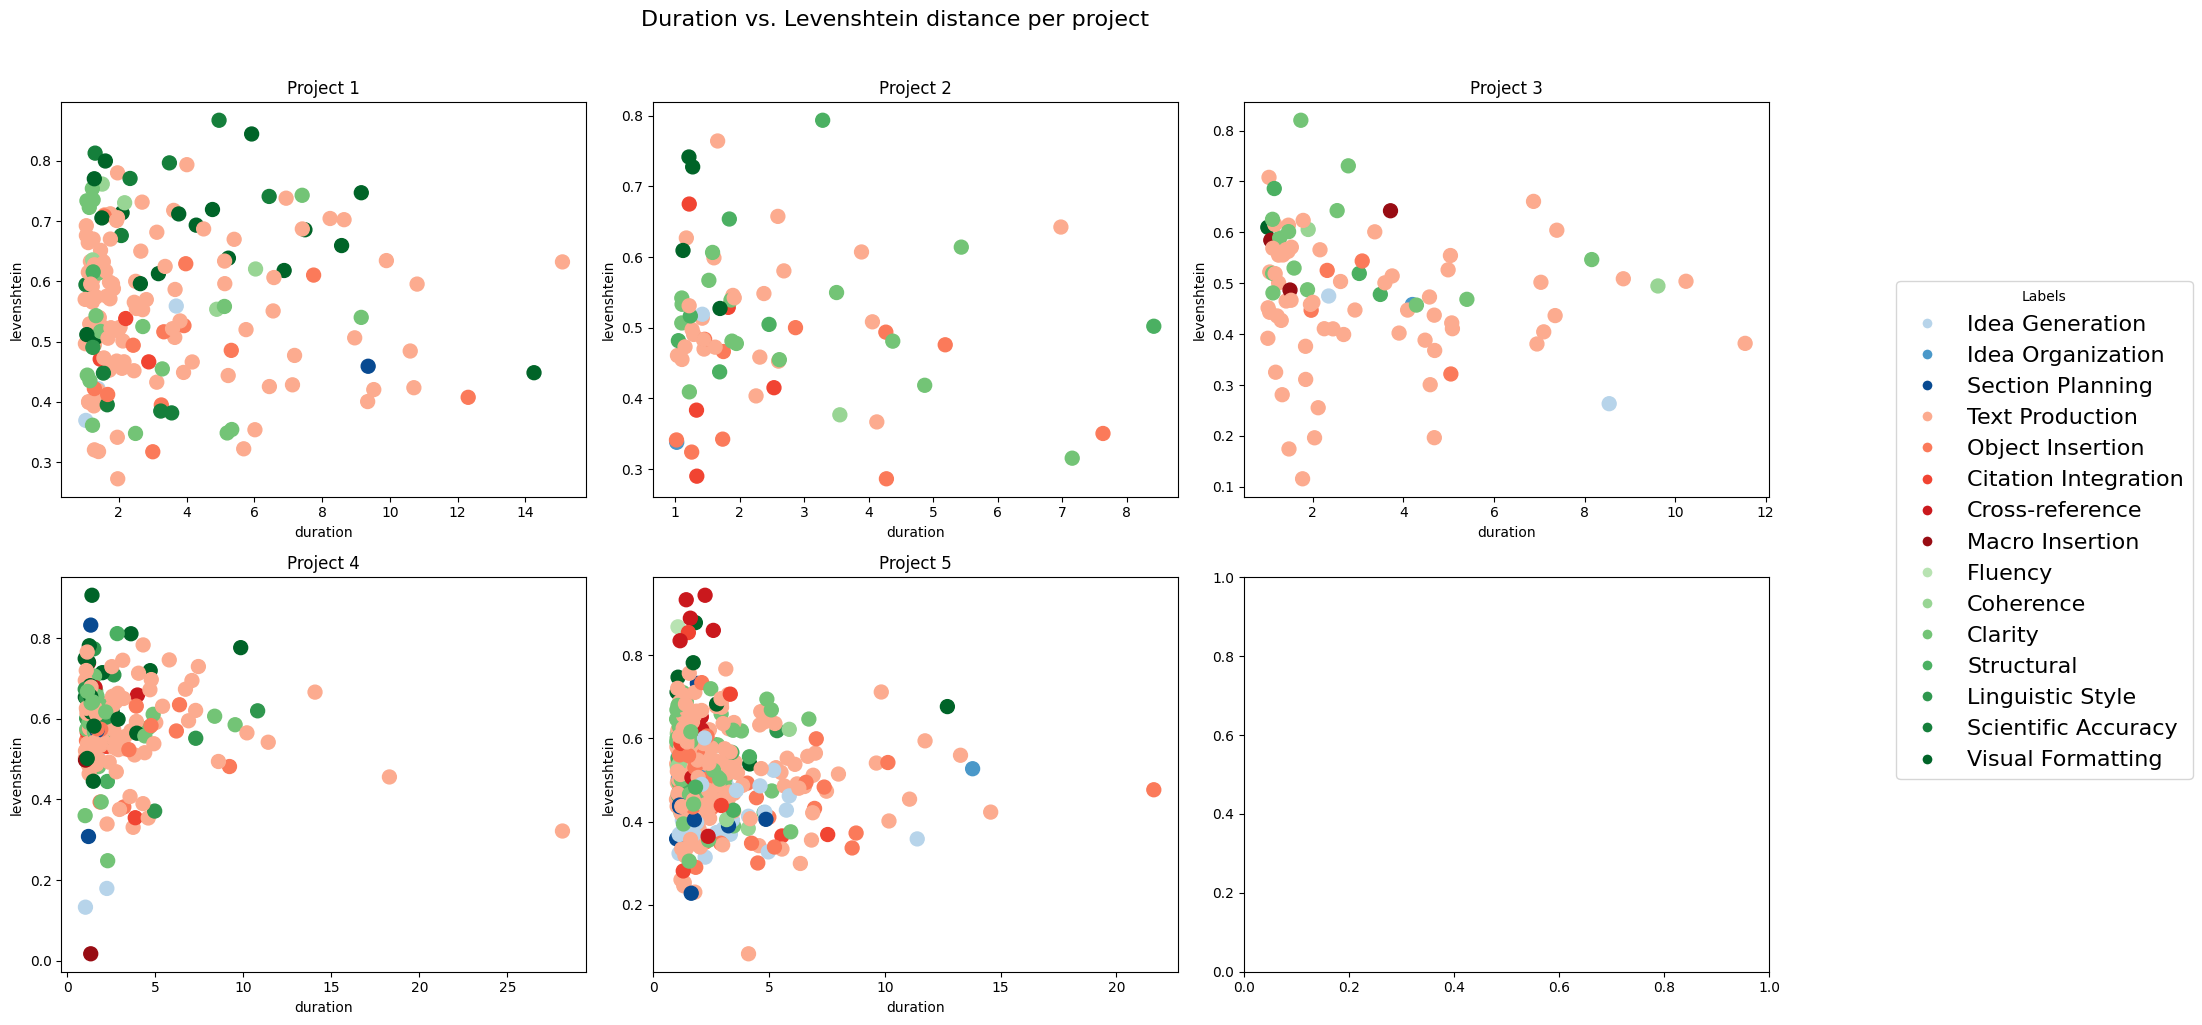

In [6]:
# Assign base colormaps for categories
base_colors = {
    "Planning": "Blues",
    "Implementation": "Reds",
    "Revision": "Greens"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(1, 6):
    with open(f"intent_session_experiment/levenshtein/{model}/project_{idx}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    label_list = [rec['label'] for rec in data]
    print(max(duration_list))

    # Build label_colors mapping (consistent across plots)
    label_colors = {}
    for cat, labs in category_map.items():
        cmap = cm.get_cmap(base_colors[cat])
        n = len(labs)
        shades = np.linspace(0.3, 0.9, n)
        for j, lab in enumerate(labs):
            label_colors[lab] = cmap(shades[j])

    point_colors = [label_colors[lab] for lab in label_list]

    ax = axes[idx-1]
    ax.scatter(duration_list, lev_list, c=point_colors, s=100)
    ax.set_title(f"Project {idx}")
    ax.set_xlabel("duration")
    ax.set_ylabel("levenshtein")



# Create a shared legend (one for all labels)
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      label=lab, markerfacecolor=label_colors[lab],
                      markersize=8) for lab in label_colors]
fig.legend(handles=handles, title="Labels",
           bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=16)

plt.suptitle("Duration vs. Levenshtein distance per project", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("figs/intention_session_duration_vs_levenshtein_per_project.png")
plt.show()

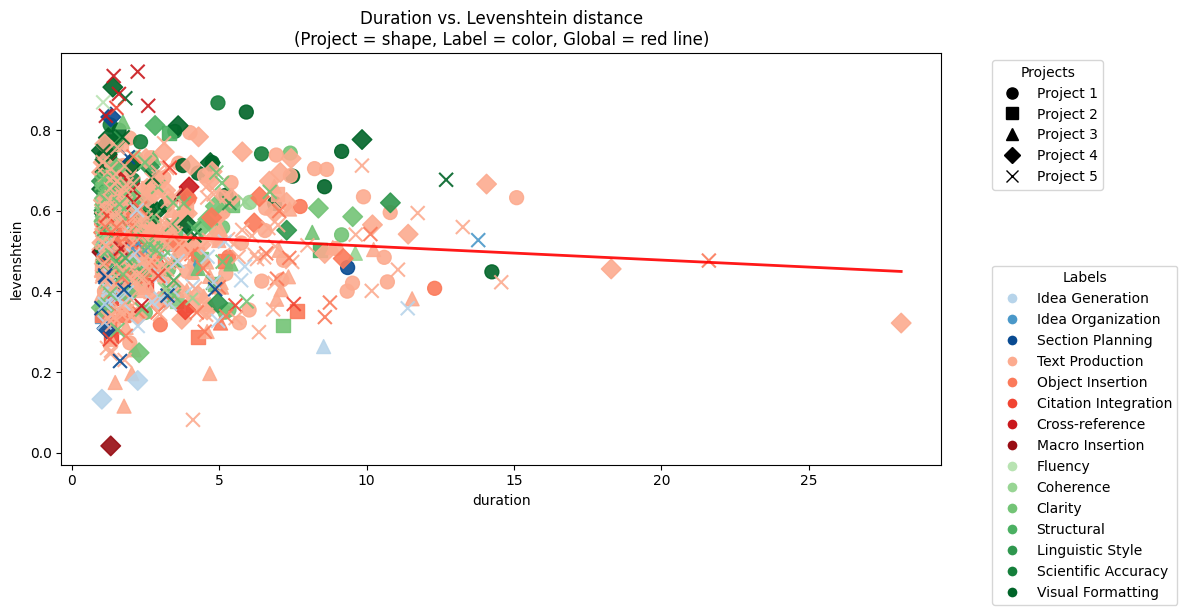

In [18]:
base_colors = {
    "Planning": "Blues",
    "Implementation": "Reds",
    "Revision": "Greens"
}

# Create a label → color mapping (same across all projects)
label_colors = {}
for cat, labs in category_map.items():
    cmap = cm.get_cmap(base_colors[cat])
    n = len(labs)
    shades = np.linspace(0.3, 0.9, n)
    for i, lab in enumerate(labs):
        label_colors[lab] = cmap(shades[i])

# Define markers for projects
project_markers = ["o", "s", "^", "D", "x"]  # 5 projects

plt.figure(figsize=(12, 6))

all_durations = []
all_levs = []

for proj_idx in range(1, 6):
    with open(f"intent_session_experiment/levenshtein/{model}/project_{proj_idx}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['levenshtein'] for rec in data]
    label_list = [rec['label'] for rec in data]

    # collect for global regression
    all_durations.extend(duration_list)
    all_levs.extend(lev_list)

    point_colors = [label_colors[lab] for lab in label_list]

    plt.scatter(duration_list, lev_list,
                c=point_colors, marker=project_markers[proj_idx-1],
                s=100, alpha=0.9, label=f"Project {proj_idx}")

# --- Global regression line (all projects combined) ---
if len(all_durations) > 1:
    m, b = np.polyfit(all_durations, all_levs, 1)
    x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
    plt.plot(x_sorted, m * x_sorted + b,
             color="red", linewidth=2, alpha=0.9, label="Global trend")

# --- Legends ---
project_handles = [plt.Line2D([0], [0], marker=m, color='k', linestyle="",
                              markersize=8, label=f"Project {i+1}")
                   for i, m in enumerate(project_markers)]
proj_legend = plt.legend(handles=project_handles, title="Projects",
                         bbox_to_anchor=(1.05, 1), loc="upper left")

label_handles = [plt.Line2D([0], [0], marker='o', color='w',
                            label=lab, markerfacecolor=label_colors[lab],
                            markersize=8) for lab in label_colors]
plt.legend(handles=label_handles, title="Labels",
           bbox_to_anchor=(1.05, 0.5), loc="upper left")

plt.gca().add_artist(proj_legend)  # keep both legends

plt.xlabel("duration")
plt.ylabel("levenshtein")
plt.title("Duration vs. Levenshtein distance\n(Project = shape, Label = color, Global = red line)")
plt.tight_layout()
plt.savefig("figs/intention_session_duration_vs_levenshtein_aggregated_project.pdf")
plt.show()


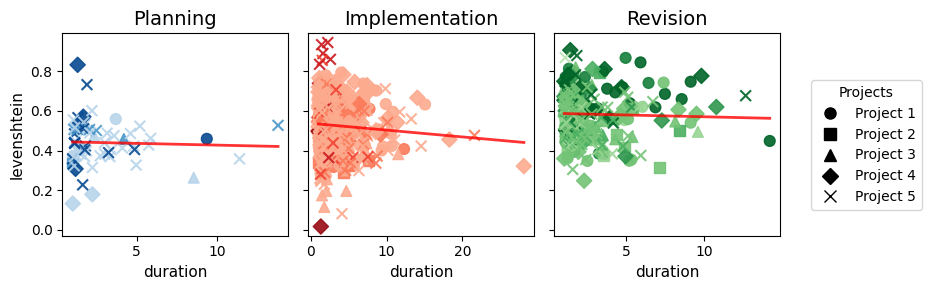

In [ ]:
# Flatten all labels across categories
all_labels = []
for cat in base_colors:
    all_labels.extend(category_map[cat])

# 1 subplot per category
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

for ax, (cat, labs) in zip(axes, category_map.items()):
    all_durations = []
    all_levs = []

    for proj_idx in range(1, 6):
        with open(f"intent_session_experiment/levenshtein/{model}/project_{proj_idx}.jsonl", "r") as f:
            data = [json.loads(line) for line in f]

        # Collect all data for the labels in this category
        duration_list = [rec['duration'] for rec in data if rec['label'] in labs]
        lev_list      = [rec['levenshtein'] for rec in data if rec['label'] in labs]
        label_list    = [rec['label'] for rec in data if rec['label'] in labs]

        # Add to global for regression
        all_durations.extend(duration_list)
        all_levs.extend(lev_list)

        # Scatter per project (color by label, marker by project)
        point_colors = [label_colors[lab] for lab in label_list]
        ax.scatter(duration_list, lev_list,
                   c=point_colors, marker=project_markers[proj_idx-1],
                   s=60, alpha=0.9, label=f"Project {proj_idx}")

    # --- Global regression line (per category, across all labels) ---
    if len(all_durations) > 1:
        m, b = np.polyfit(all_durations, all_levs, 1)
        x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
        ax.plot(x_sorted, m * x_sorted + b,
                color="red", linewidth=2, alpha=0.8, label="Global trend")

    ax.set_title(cat, fontsize=14)
    ax.set_xlabel("duration", fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel("levenshtein", fontsize=11)

# Shared legend (projects only, outside the plot)
project_handles = [
    plt.Line2D([0], [0], marker=m, color='k', linestyle="", markersize=8,
               label=f"Project {i+1}") 
    for i, m in enumerate(project_markers)
]
fig.legend(handles=project_handles, title="Projects",
           loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

plt.tight_layout()
plt.savefig("figs/intention_session_by_category.pdf")
plt.show()


### BERT score

#### generate result

In [7]:
from bert_score import score

/home/chi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
for i in range(5, 6):
    folder = f"intent_session_experiment/generated_output/{model}/{i}"
    files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    idx_set = set([int(file.split(".")[0]) for file in files])
    
    with open(f"intent_session/project_{i}_intent_session.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
        
    human_output_list = []
    model_output_list = []
    index_list = []
    duration_list = []
    label_list = []
    store = []
    
    for rec in data:
        if rec['index'] in idx_set:
            # model output
            with open(f"{folder}/{rec['index']}.txt", "r") as f:
                raw_output = f.read()
            model_output_list.append(strip_code_fences(raw_output))
            human_output_list.append(rec["after_text"])
            index_list.append(rec["index"])
            duration_list.append(rec["duration"])
            label_list.append(rec["label"])


    # compute BERTScore (batch mode)
    # P, R, F1 = score(cands, refs, lang="en")
    _, _, F1 = score(model_output_list, human_output_list, lang="en")

    # attach results back to records
    for index, duration, label, f in zip(index_list, duration_list, label_list, F1):
        record = {
                "index": index,
                "duration": duration,
                "bert5core_f1": f.item(),
                "label": label,
            }
        store.append(record)
        
    output_file = f"intent_session_experiment/bertscore_f1/{model}/project_{i}.jsonl"
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, "w") as f:
        for record in store:
            f.write(json.dumps(record) + "\n")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/chi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/chi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


#### plot

15.09165
8.4190833333
11.54615
28.13845
21.61375


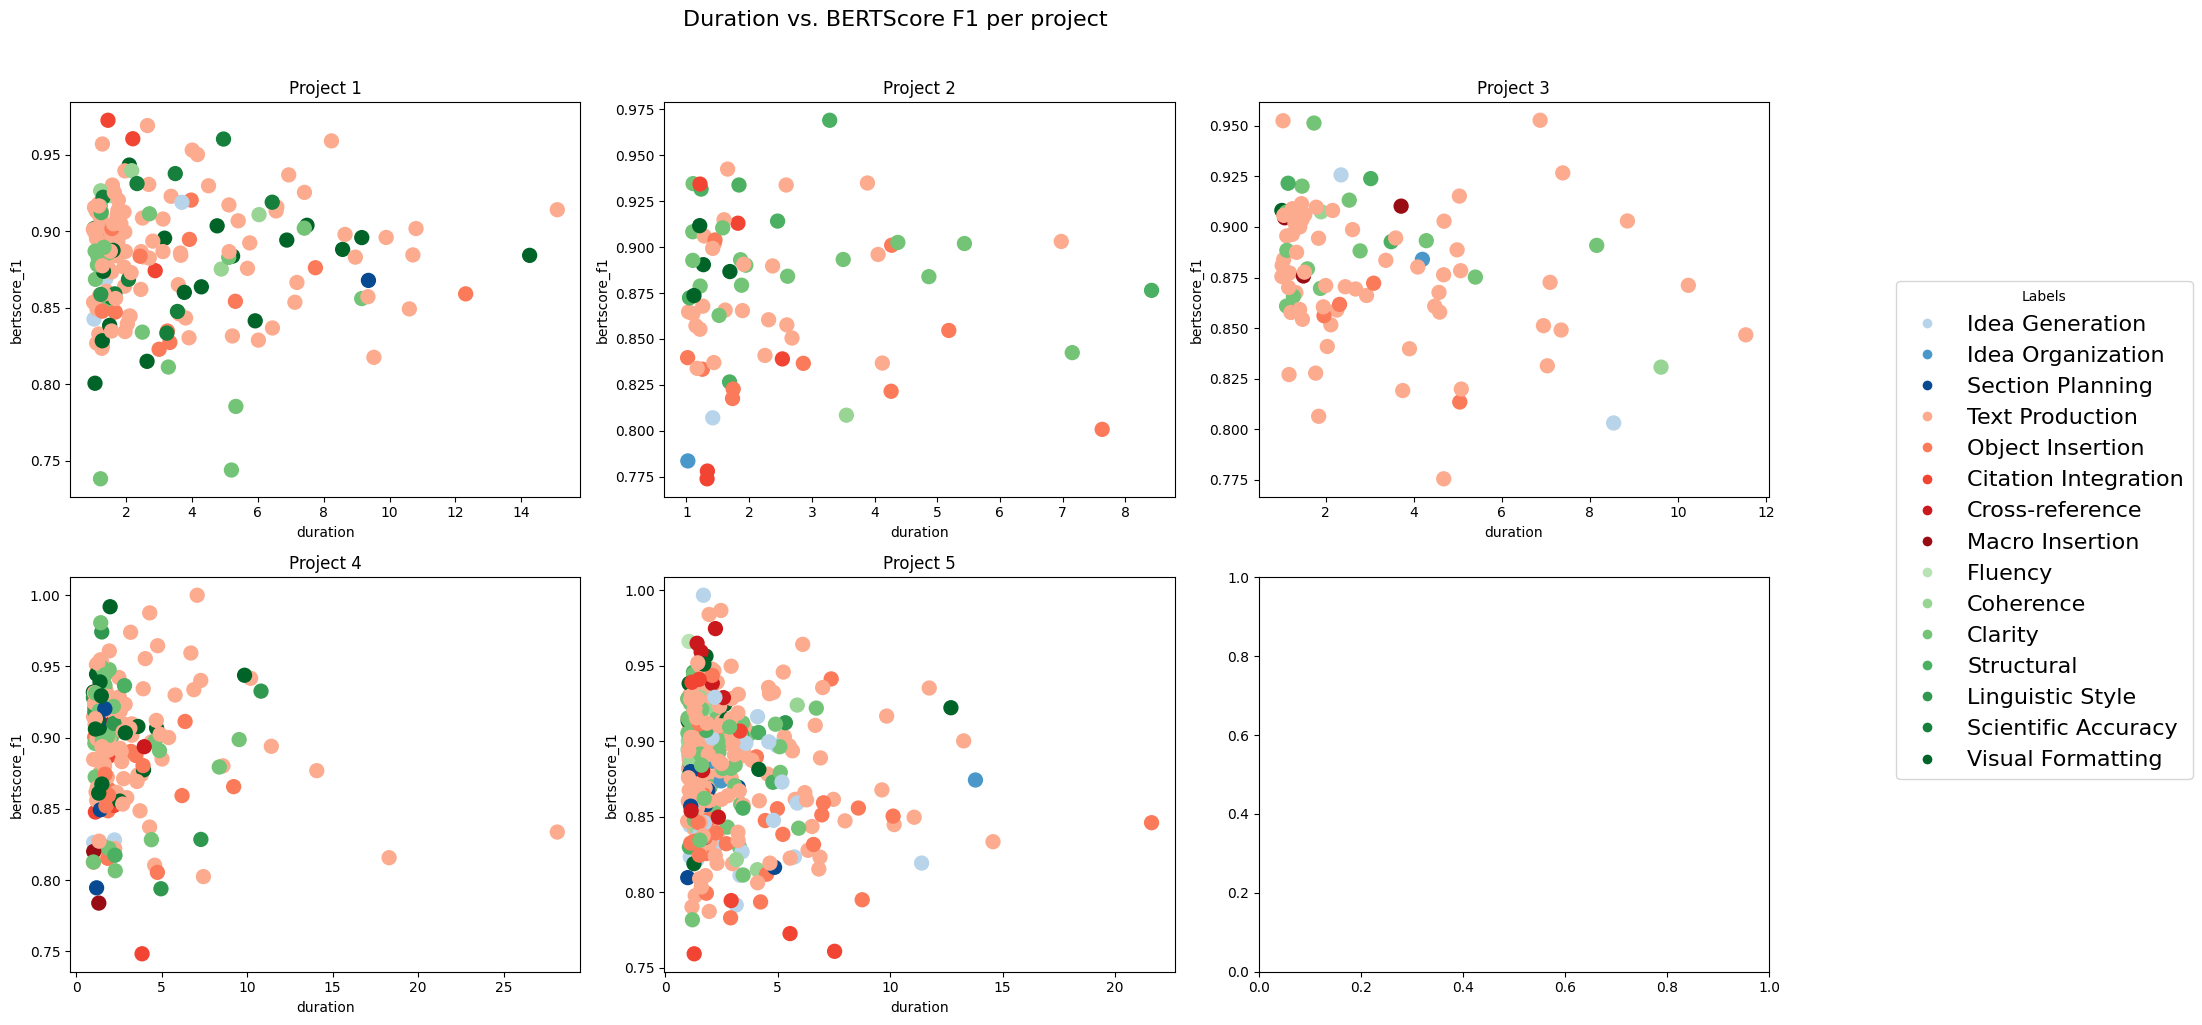

In [7]:
# Assign base colormaps for categories
base_colors = {
    "Planning": "Blues",
    "Implementation": "Reds",
    "Revision": "Greens"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(1, 6):
    with open(f"intent_session_experiment/bertscore_f1/{model}/project_{idx}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['bertscore_f1'] for rec in data]
    label_list = [rec['label'] for rec in data]
    print(max(duration_list))

    # Build label_colors mapping (consistent across plots)
    label_colors = {}
    for cat, labs in category_map.items():
        cmap = cm.get_cmap(base_colors[cat])
        n = len(labs)
        shades = np.linspace(0.3, 0.9, n)
        for j, lab in enumerate(labs):
            label_colors[lab] = cmap(shades[j])

    point_colors = [label_colors[lab] for lab in label_list]

    ax = axes[idx-1]
    ax.scatter(duration_list, lev_list, c=point_colors, s=100)
    ax.set_title(f"Project {idx}")
    ax.set_xlabel("duration")
    ax.set_ylabel("bertscore_f1")



# Create a shared legend (one for all labels)
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      label=lab, markerfacecolor=label_colors[lab],
                      markersize=8) for lab in label_colors]
fig.legend(handles=handles, title="Labels",
           bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=16)

plt.suptitle("Duration vs. BERTScore F1 per project", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("figs/intention_session_duration_vs_bertscore_f1_per_project.png")
plt.show()

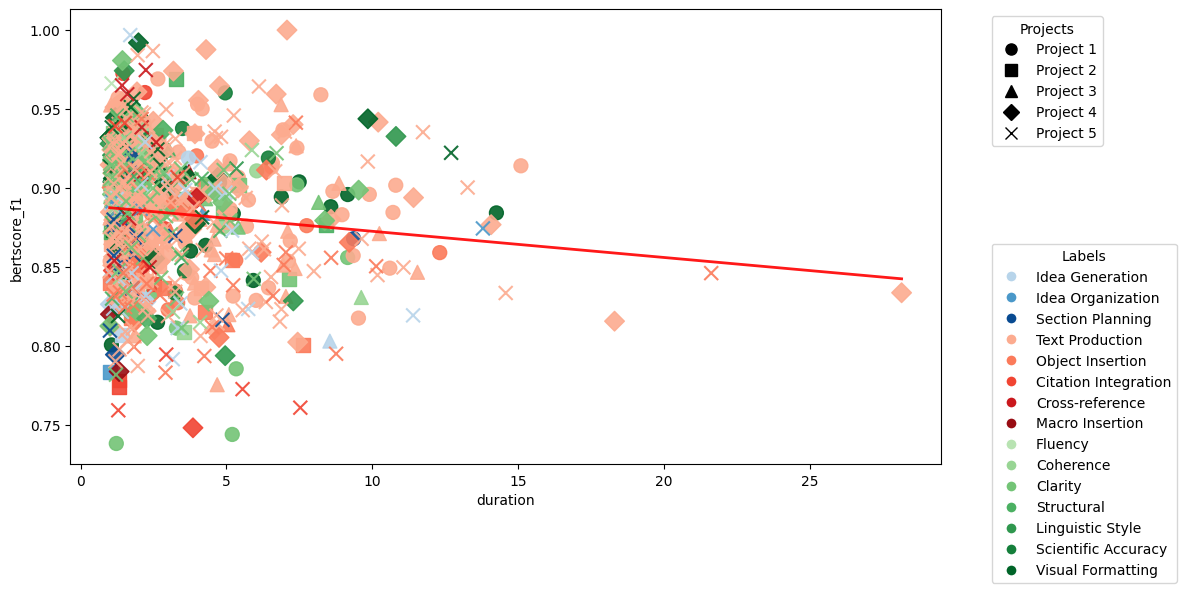

In [14]:
base_colors = {
    "Planning": "Blues",
    "Implementation": "Reds",
    "Revision": "Greens"
}

# Create a label → color mapping (same across all projects)
label_colors = {}
for cat, labs in category_map.items():
    cmap = cm.get_cmap(base_colors[cat])
    n = len(labs)
    shades = np.linspace(0.3, 0.9, n)
    for i, lab in enumerate(labs):
        label_colors[lab] = cmap(shades[i])

# Define markers for projects
project_markers = ["o", "s", "^", "D", "x"]  # 5 projects

plt.figure(figsize=(12, 6))

all_durations = []
all_levs = []

for proj_idx in range(1, 6):
    with open(f"intent_session_experiment/bertscore_f1/{model}/project_{proj_idx}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]

    duration_list = [rec['duration'] for rec in data]
    lev_list = [rec['bertscore_f1'] for rec in data]
    label_list = [rec['label'] for rec in data]
    all_durations.extend(duration_list)
    all_levs.extend(lev_list)

    point_colors = [label_colors[lab] for lab in label_list]

    plt.scatter(duration_list, lev_list,
                c=point_colors, marker=project_markers[proj_idx-1],
                s=100, alpha=0.9, label=f"Project {proj_idx}")

# --- Global regression line (all projects combined) ---
if len(all_durations) > 1:
    m, b = np.polyfit(all_durations, all_levs, 1)
    x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
    plt.plot(x_sorted, m * x_sorted + b,
             color="red", linewidth=2, alpha=0.9, label="Global trend")
    
# --- Legends ---
# Project legend (shapes)
project_handles = [plt.Line2D([0], [0], marker=m, color='k', linestyle="",
                              markersize=8, label=f"Project {i+1}")
                   for i, m in enumerate(project_markers)]
proj_legend = plt.legend(handles=project_handles, title="Projects",
                         bbox_to_anchor=(1.05, 1), loc="upper left")

# Label legend (colors)
label_handles = [plt.Line2D([0], [0], marker='o', color='w',
                            label=lab, markerfacecolor=label_colors[lab],
                            markersize=8) for lab in label_colors]
plt.legend(handles=label_handles, title="Labels",
           bbox_to_anchor=(1.05, 0.5), loc="upper left")

plt.gca().add_artist(proj_legend)  # keep both legends

plt.xlabel("duration")
plt.ylabel("bertscore_f1")
# plt.title("Duration vs. BERTScore F1\n(Project = shape, Label = color)")
plt.tight_layout()
plt.savefig("figs/intention_session_duration_vs_bertscore_f1_aggregated_project_gpt5.pdf")

plt.show()

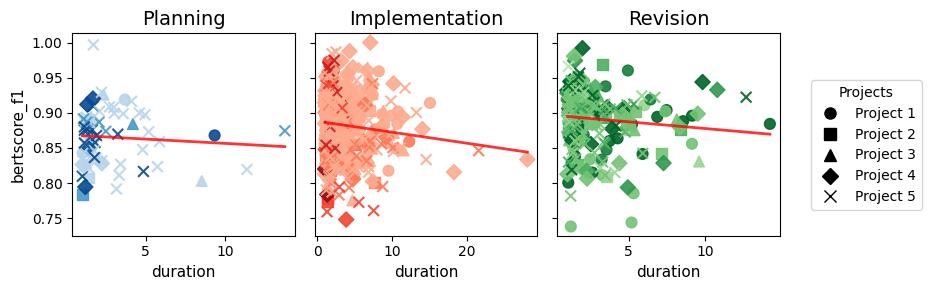

In [13]:
# Flatten all labels across categories
all_labels = []
for cat in base_colors:
    all_labels.extend(category_map[cat])

# 1 subplot per category
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

for ax, (cat, labs) in zip(axes, category_map.items()):
    all_durations = []
    all_levs = []

    for proj_idx in range(1, 6):
        with open(f"intent_session_experiment/bertscore_f1/{model}/project_{proj_idx}.jsonl", "r") as f:
            data = [json.loads(line) for line in f]

        # Collect all data for the labels in this category
        duration_list = [rec['duration'] for rec in data if rec['label'] in labs]
        lev_list      = [rec['bertscore_f1'] for rec in data if rec['label'] in labs]
        label_list    = [rec['label'] for rec in data if rec['label'] in labs]

        # Add to global for regression
        all_durations.extend(duration_list)
        all_levs.extend(lev_list)

        # Scatter per project (color by label, marker by project)
        point_colors = [label_colors[lab] for lab in label_list]
        ax.scatter(duration_list, lev_list,
                   c=point_colors, marker=project_markers[proj_idx-1],
                   s=60, alpha=0.9, label=f"Project {proj_idx}")

    # --- Global regression line (per category, across all labels) ---
    if len(all_durations) > 1:
        m, b = np.polyfit(all_durations, all_levs, 1)
        x_sorted = np.linspace(min(all_durations), max(all_durations), 100)
        ax.plot(x_sorted, m * x_sorted + b,
                color="red", linewidth=2, alpha=0.8, label="Global trend")

    ax.set_title(cat, fontsize=14)
    ax.set_xlabel("duration", fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel("bertscore_f1", fontsize=11)

# Shared legend (projects only, outside the plot)
project_handles = [
    plt.Line2D([0], [0], marker=m, color='k', linestyle="", markersize=8,
               label=f"Project {i+1}") 
    for i, m in enumerate(project_markers)
]
fig.legend(handles=project_handles, title="Projects",
           loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

plt.tight_layout()
plt.savefig("figs/intention_session_duration_vs_bertscore_by_category_gpt5.pdf")
plt.show()
